# BS6201 AI Assignment 4
#### Yaoding Chen
----
Explore white wine dataset, follow what we did with red wine data
- share 2 observations within the dataset (white wine itself)
- share 2 observations across the two datasets (red vs white wine dataset)

Bonus:
- Use other kinds of visualization apart from boxplot
- Feel free to come up with a data story. Something you'd like to share about the dataset / interesting observation
----

## 1. Descriptive analytics

Here we aim to analyse the data from a dataset detailing a variety of features of white wine samples, which is from:
- P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. Modeling wine preferences by data mining from physicochemical properties. In Decision Support Systems, Elsevier, 47(4):547-553, 2009.

As the physicochemical properties may affect its quality to different extents, we aim to identify feature importance and to explore an effient model using the least features.

----

### 1.1 Data Preparations

Before we formally start, we need to load the libraries and the data for this research with the following Python code:

In [1]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import shapiro
from scipy.stats import stats as st

In [2]:
# import dataset
white_wine = pd.read_csv('winequality-white.csv', sep = ';')
red_wine = pd.read_csv('winequality-red.csv', sep = ';')

Then we should look at the data, and the features we have, and whether there are missing data.

In [3]:
print(white_wine.shape) # check data size
print(white_wine.columns) # check dimensions

(4898, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [4]:
white_wine.describe() # data summary

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [5]:
white_wine.isnull().sum() # check missing data

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

As indicated above, the dataset has no missing data and is a dataset consisting of 12 features of 4898 white wine samples. The features include 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar','chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density','pH', 'sulphates', 'alcohol', 'quality'.

----

### 1.2 Normality test

Since we are interested in how other data affect quality, it may be important to first observe the quality distribution of the sample to understand whether the dataset include samples with enough variance of quality or whether the data is biased towards specific wine quality.

In [6]:
white_wine['quality'].describe()

count    4898.000000
mean        5.877909
std         0.885639
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64

(array([  20.,  163.,    0., 1457.,    0., 2198.,  880.,    0.,  175.,
           5.]),
 array([3. , 3.6, 4.2, 4.8, 5.4, 6. , 6.6, 7.2, 7.8, 8.4, 9. ]),
 <BarContainer object of 10 artists>)

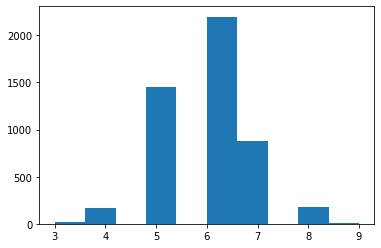

In [7]:
# draw histogram
plt.hist(white_wine['quality'])

/home/azureuser/.local/lib/python3.8/site-packages/statsmodels/graphics/gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


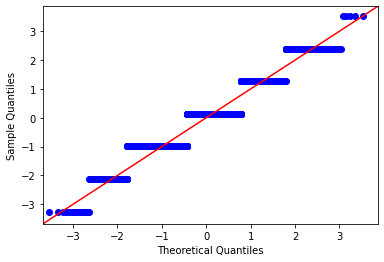

In [8]:
# draw Q-Q plot
qqplot(white_wine['quality'], fit=True, line = '45')
plt.show()

In [9]:
#qqplot(white_wine['volatile acidity'], fit=True, line = '45')
#plt.show()

In [10]:
# Shapiro-Wilk Test
quality_stat, quality_p = shapiro(white_wine['quality'])
print(quality_stat, quality_p)
# interpret
alpha = 0.05
if quality_p > alpha:
	print('Sample looks Gaussian (fail to reject H0)')
else:
	print('Sample does not look Gaussian (reject H0)')

0.8890228271484375 0.0
Sample does not look Gaussian (reject H0)


The histogram, the Q-Q plot, and the Shapiro-Wilk Test result all show that the quality of the wine is not normally distributed, which means we should be careful when applying models (e.g. linear regression model) requiring normal distribution.

Then the question is how about the quality of red wine. Does the distribution looks similar to white wine or differ a lot? Can they are consider the same population statistically when studying the wine quality? Are there any biases towards any kind of wine even before we study any specific features?

In [11]:
red_wine['quality'].describe()

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

/home/azureuser/.local/lib/python3.8/site-packages/statsmodels/graphics/gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


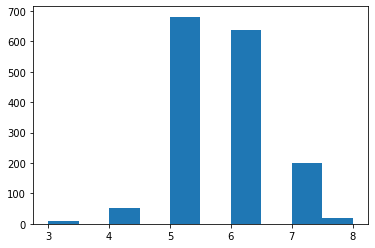

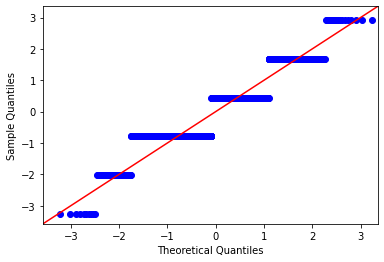

0.8575843572616577 9.504003839923922e-36
Sample does not look Gaussian (reject H0)


In [12]:
# draw histogram
plt.hist(red_wine['quality'])

# draw Q-Q plot
qqplot(red_wine['quality'], fit=True, line = '45')
plt.show()

# Shapiro-Wilk Test
quality_stat, quality_p = shapiro(red_wine['quality'])
print(quality_stat, quality_p)
# interpret
alpha = 0.05
if quality_p > alpha:
	print('Sample looks Gaussian (fail to reject H0)')
else:
	print('Sample does not look Gaussian (reject H0)')

As above, we apply the same techniques applying to white wine quality data to red wine data, which shows a similar non-normal distribution. Then we may use two-sample t-test to tell whether the quality distribution of the two sample classes are different in quality. 

In [13]:
st.ttest_ind(white_wine['quality'],red_wine['quality'])

Ttest_indResult(statistic=9.685649554187696, pvalue=4.888069044201508e-22)

The t-test result shows that the two wine classes are different in quality and may not be considered the same population. So, maybe we should analyse the data seprately and it may be expected that the two wine classes may have different feature importance.

### 1.3 Identifying outliers

However, when we look more closely to the two datasets as below:

In [64]:
# sns.boxplot(red_wine['quality'])
# sns.boxplot(white_wine['quality'])

In [65]:
# data merger
redwine_quality = pd.DataFrame(
    {'type' : ["Red Wine"]*len(red_wine), 'quality': list(red_wine['quality'])},
    columns= ['type','quality'])
whitewine_quality = pd.DataFrame(
    {'type' : ["White Wine"]*len(white_wine), 'quality': list(white_wine['quality'])},
    columns= ['type','quality'])
quality_data = pd.concat([redwine_quality,whitewine_quality])
# quality_data

/home/azureuser/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='type', ylabel='quality'>

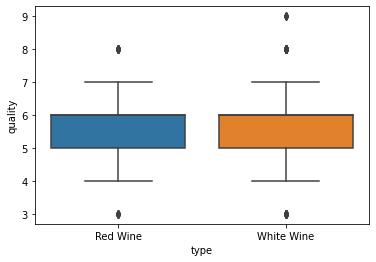

In [66]:
sns.boxplot(quality_data["type"], quality_data["quality"])

/home/azureuser/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='type', ylabel='quality'>

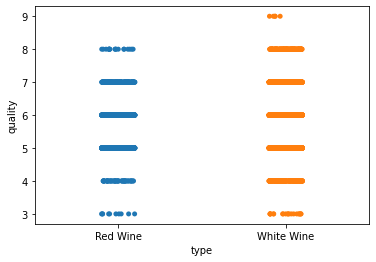

In [67]:
sns.stripplot(quality_data["type"], quality_data["quality"])

As shown above (both in the boxplot and strip plot), it has been clear that most samples, either of red and white wine, are mostly rated 5-6, with a similar 25-75% percentile between 4-7. The only difference is that white wine have much more samples rated 9. 

### 1.4 Impact of removing outliers

However, further steps can be taken to study how this will impact the overall data. Here we try to remove those samples from the dataset and see how they affect the summary data and t-test results.

Here the t-test result show that the two quality datasets are still quite different, which shows a low impact of removing these data on the overall quality. Although we have show that these values are a difference between the two datasets, but they are not the major one.

In [71]:
#quality_data_adjusted[quality_data_adjusted['type']=="Red Wine"]["quality"].describe()
#quality_data_adjusted[quality_data_adjusted['type']=="White Wine"]["quality"].describe()

In [78]:
# define a function
def mean_std_df(treatment,data):
    std = np.std(list(data))
    mean = np.mean(list(data))
    df = {"treatment": treatment,
         "mean":mean,
         "std":std}
    return df

quality_data_adjusted2 = quality_data_adjusted[ (quality_data_adjusted['quality'] != 3) ]
whitewine_treatment_data = pd.DataFrame([mean_std_df("original data",white_wine['quality']),
                                         mean_std_df("remove quality rated 9 data", quality_data_adjusted[quality_data_adjusted['type']=="White Wine"]["quality"]),
                                         mean_std_df("remove quality rated 3 and 9 data",quality_data_adjusted2[quality_data_adjusted2['type']=="White Wine"]["quality"])])
redwine_treatment_data = pd.DataFrame([mean_std_df("original data",red_wine['quality']),
                                         mean_std_df("remove quality rated 9 data", quality_data_adjusted[quality_data_adjusted['type']=="Red Wine"]["quality"]),
                                         mean_std_df("remove quality rated 3 and 9 data",quality_data_adjusted2[quality_data_adjusted2['type']=="Red Wine"]["quality"])])

redwine_treatment_data

,treatment,mean,std
0,original data,5.636023,0.807317
1,remove quality rated 9 data,5.636023,0.807317
2,remove quality rated 3 and 9 data,5.652612,0.782213


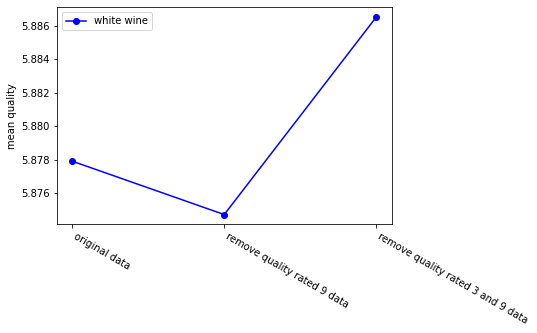

In [95]:
line2 = plt.plot(whitewine_treatment_data["treatment"], whitewine_treatment_data["mean"],'bo-', label='line2') 
#line1 = plt.plot(redwine_treatment_data["treatment"], redwine_treatment_data["mean"],'ko-')
plt.xticks(rotation=-30, ha='left')
plt.ylabel("mean quality")
plt.legend({"white wine": 'blue'})
p

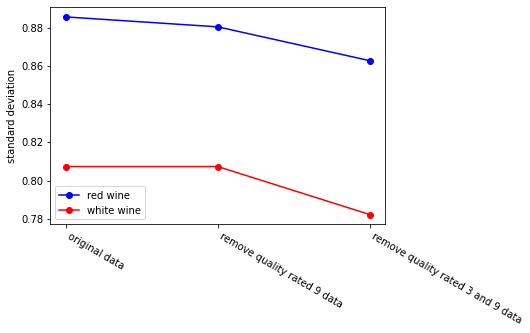

In [94]:
line2 = plt.plot(whitewine_treatment_data["treatment"], whitewine_treatment_data["std"],'bo-',label='line2') 
line1 = plt.plot(redwine_treatment_data["treatment"], redwine_treatment_data["std"],'ro-')
plt.xticks(rotation=-30, ha='left')
plt.ylabel("standard deviation")
plt.legend({"red wine": 'red', "white wine": 'blue'})
p1

In [63]:
# not a good visualisation... The std value is too large and the change is too small...
#p3 = plt.plot(treatment_data["treatment"], treatment_data["mean"],'ko-')
#plt.xticks(rotation=-30, ha='left')
#plt.errorbar(treatment_data["treatment"], treatment_data["mean"], yerr= treatment_data["std"])
#p3 

Above I visualise the outcomes of removing all outliers, which means their quality is 3 or 9 in our both datasets. The results show that although in both datasets, the standard deviation are reduced with the steps as expected, their mean changes are quite small, and the more increase after removing quality=3 data indicates that there are more outliers with quality=3. Again, after removing only quality=3 data, the boxplot is like below figure, but quality=8 data will be considered outliers when quality=3 data removed. But in both cases, the boxplots are quite similar, which indicate that boxplots may be confusing when used to identify data distribution and may be exggrating the importance of outliers.

In [97]:
quality_data_adjusted = quality_data[ (quality_data['quality'] != 9) ]
# sns.stripplot(quality_data_adjusted["type"], quality_data_adjusted["quality"])

/home/azureuser/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='type', ylabel='quality'>

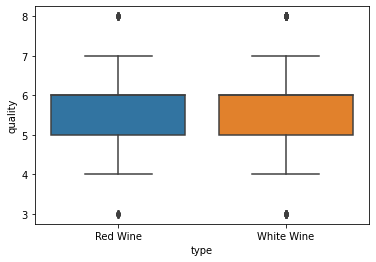

In [69]:
sns.boxplot(quality_data_adjusted["type"], quality_data_adjusted["quality"])

/home/azureuser/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='type', ylabel='quality'>

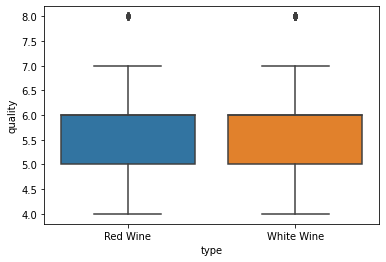

In [98]:
sns.boxplot(quality_data_adjusted2["type"], quality_data_adjusted2["quality"])

In [100]:
st.ttest_ind(quality_data_adjusted[quality_data_adjusted['type']=="Red Wine"]["quality"],
            quality_data_adjusted[quality_data_adjusted['type']=="White Wine"]["quality"])

Ttest_indResult(statistic=-9.601102073806075, pvalue=1.1015777805137112e-21)

In [101]:
st.ttest_ind(quality_data_adjusted2[quality_data_adjusted2['type']=="Red Wine"]["quality"],
            quality_data_adjusted2[quality_data_adjusted2['type']=="White Wine"]["quality"])

Ttest_indResult(statistic=-9.596802871069965, pvalue=1.1495693610390045e-21)

As the t-test results show, the two datasets are still distinct from each other despite highly similar boxplots in both cases, which suggests how easy it may be to create false sense of similarity by manipulating data and visualising them in boxplots.

----

### Finding correlation

Pair plots are interesting but the parameters are too many to find any significant relations easily...

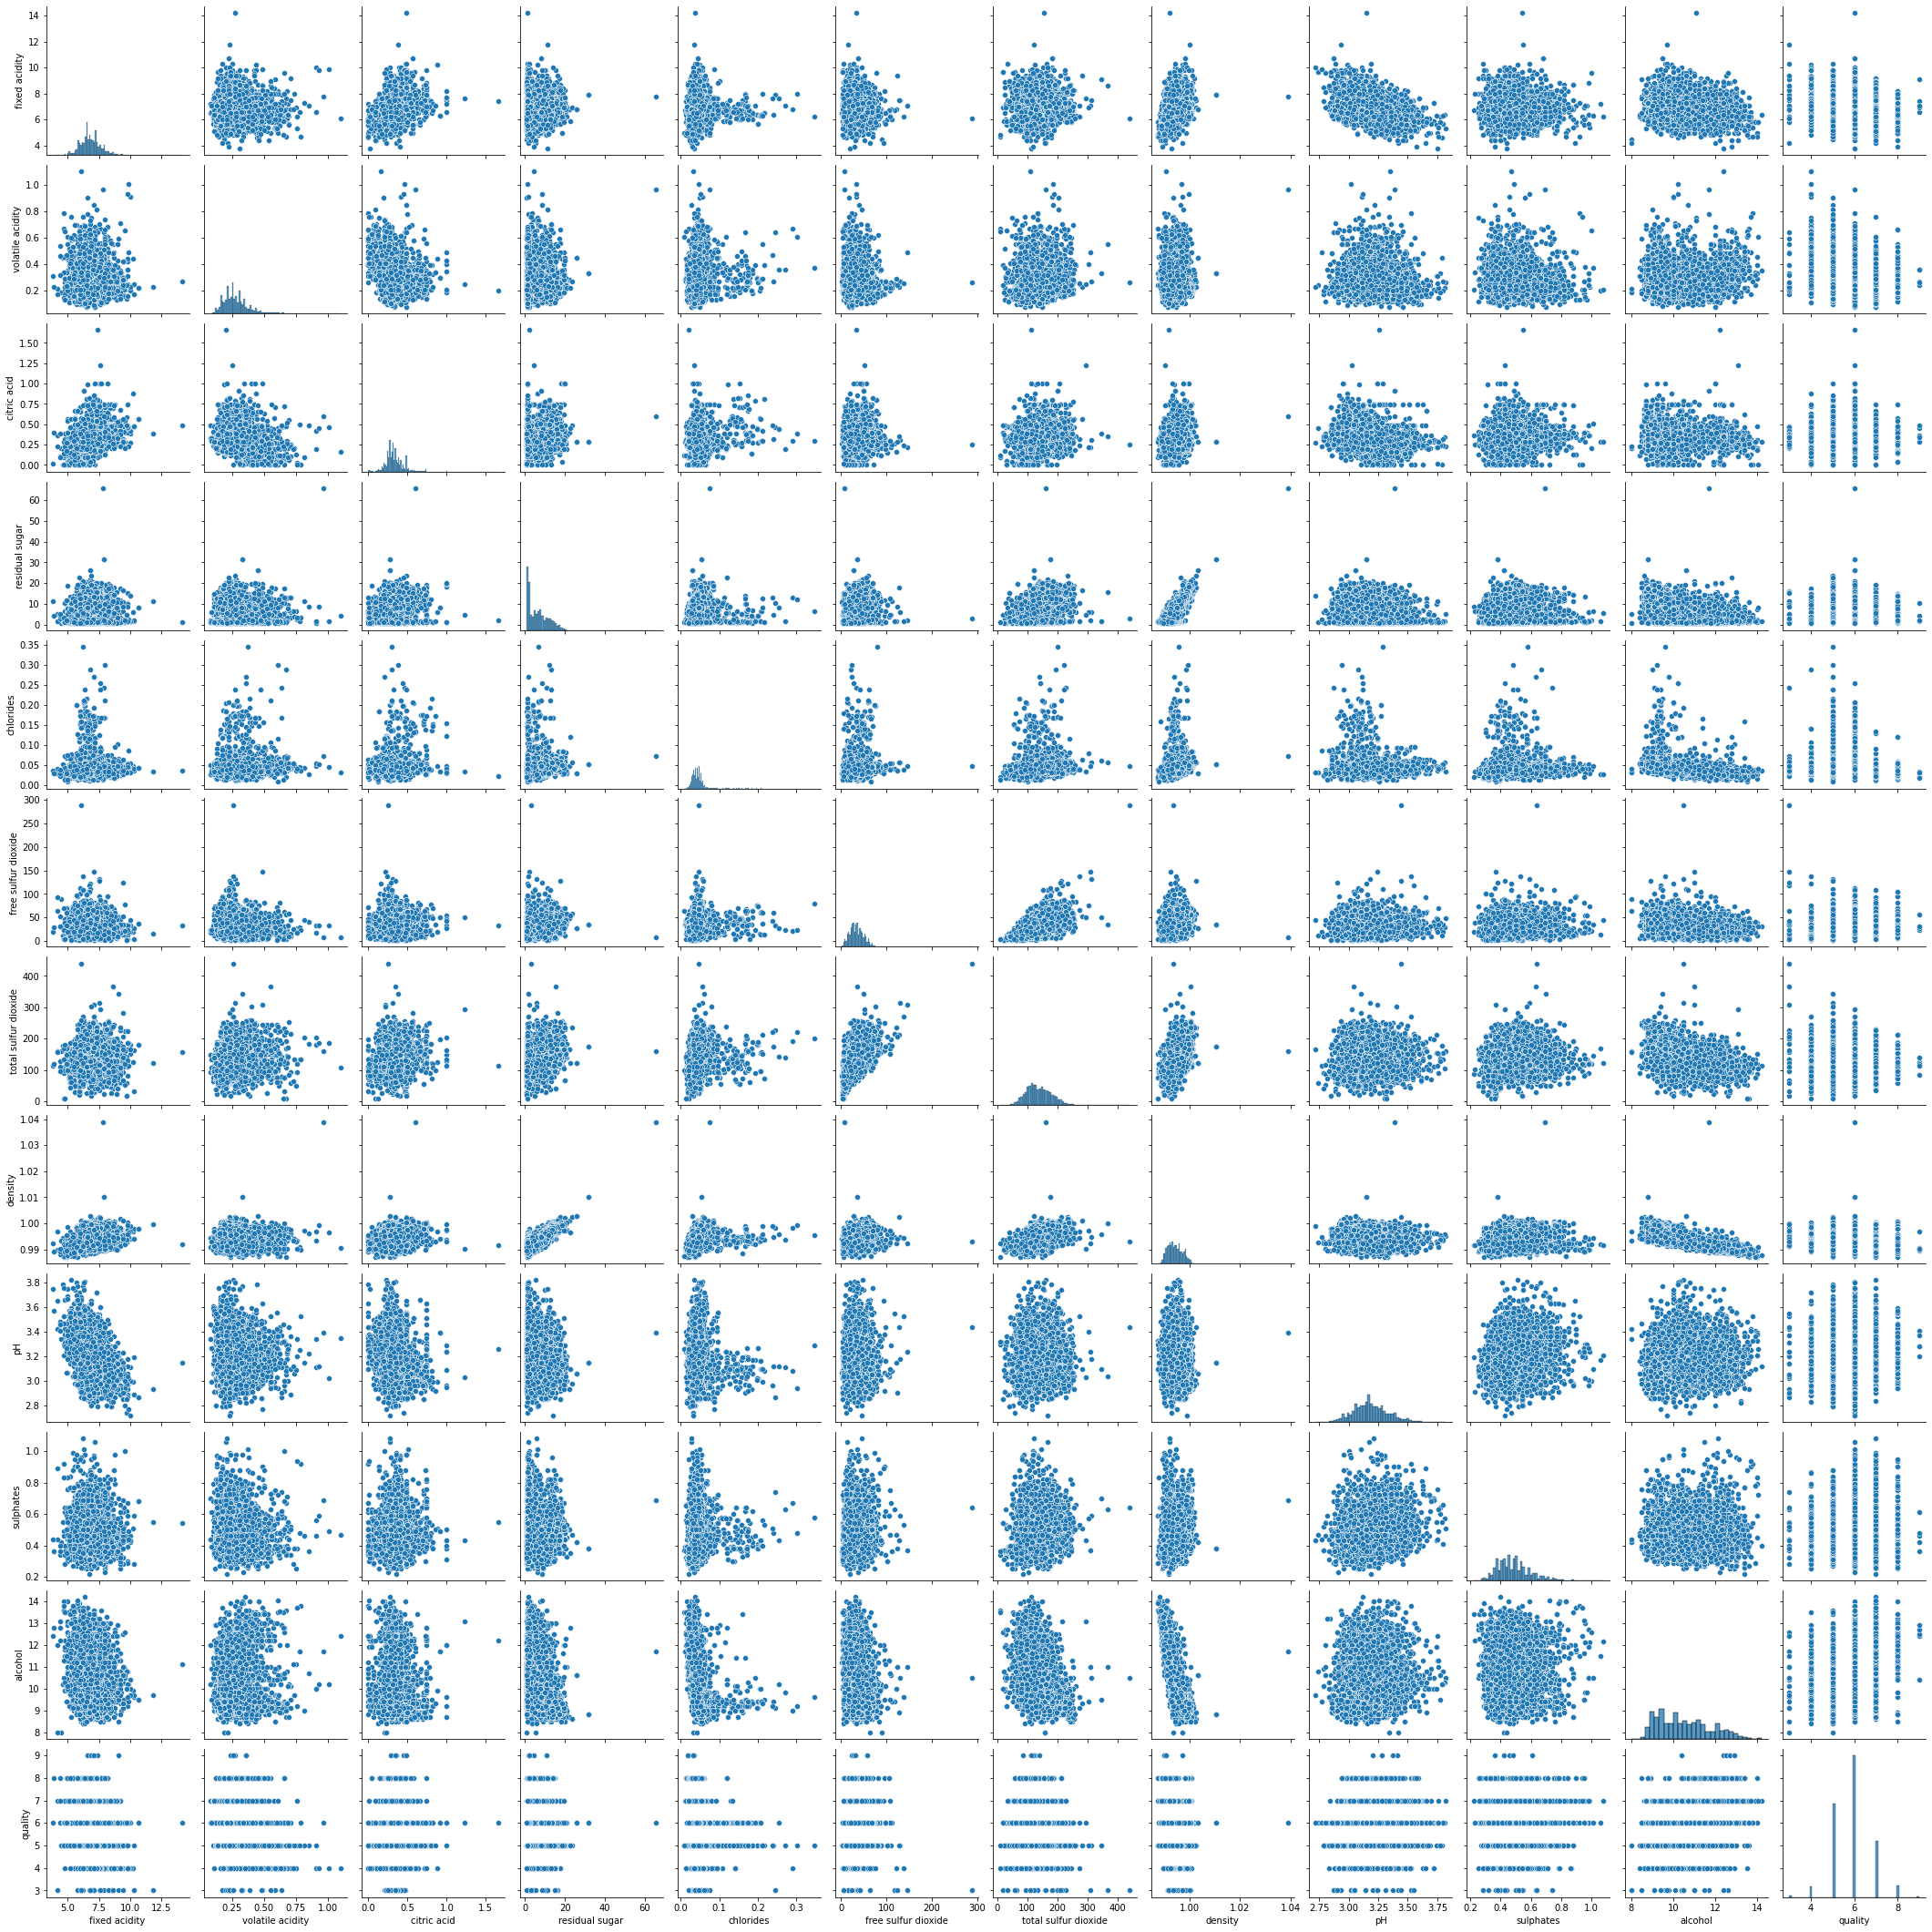

In [49]:
sns.pairplot(white_wine)

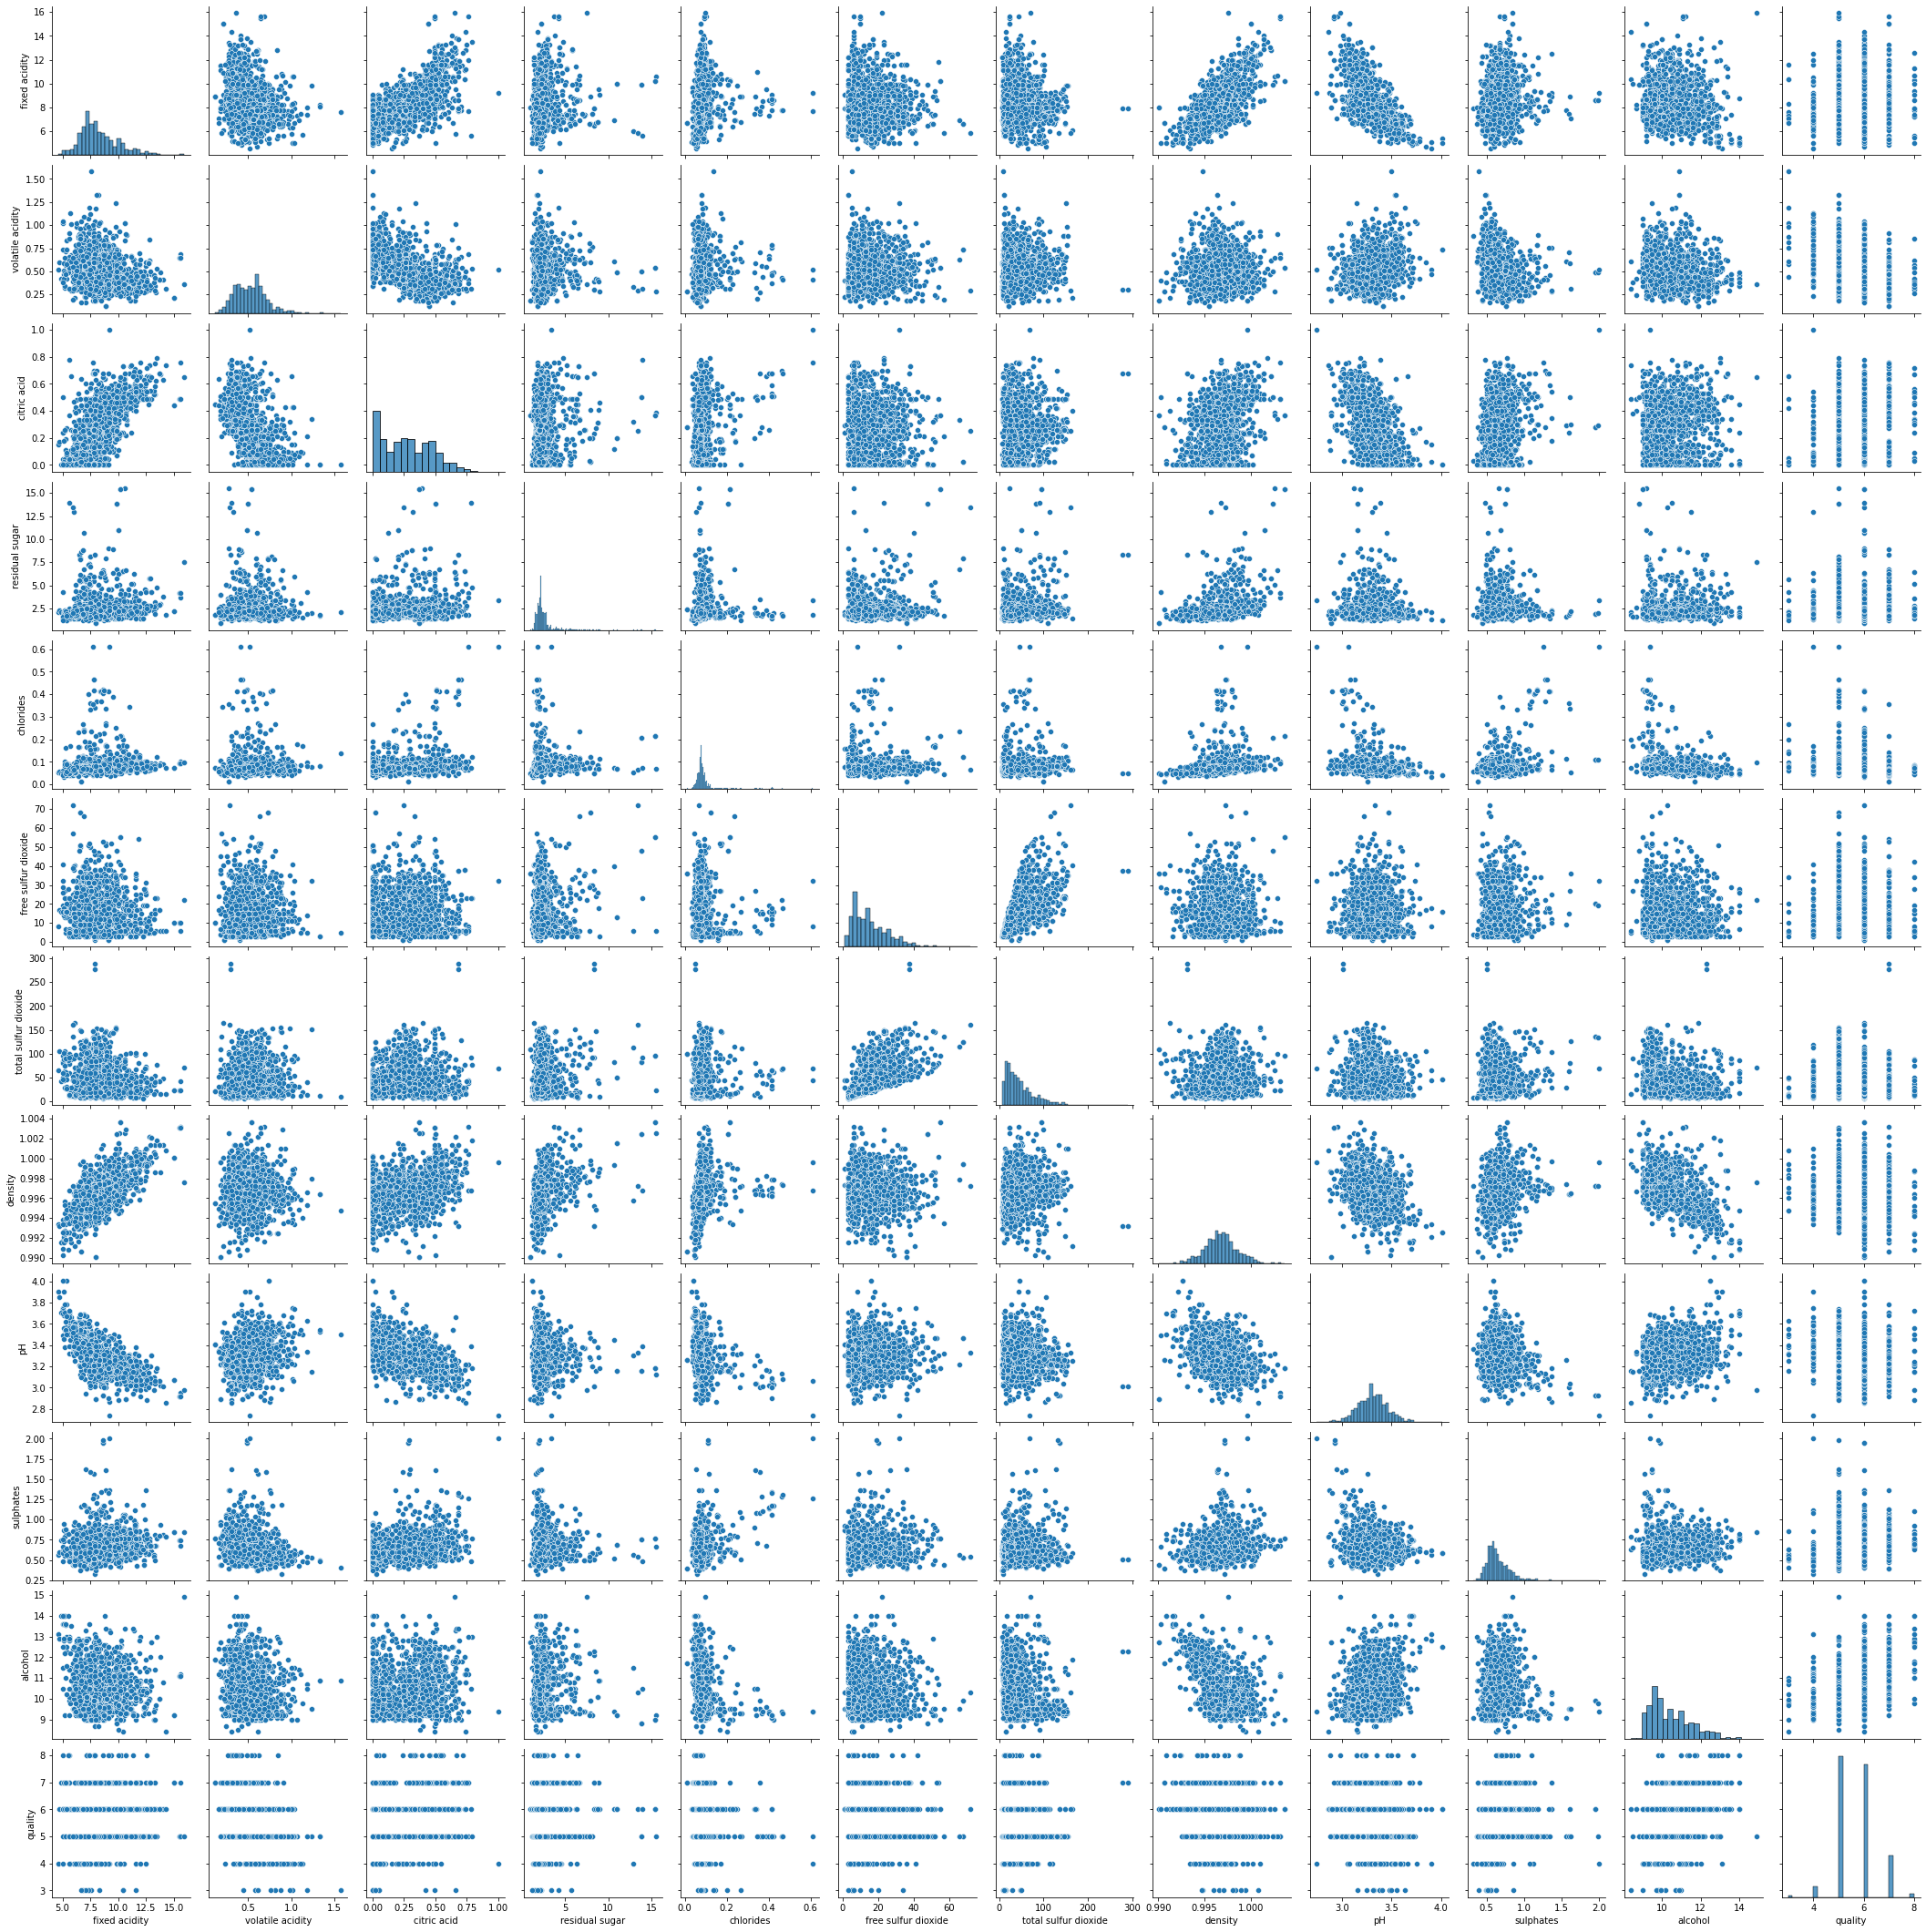

In [50]:
sns.pairplot(red_wine)

## Summary

2 observations within the dataset (white wine itself):
1. white wine quality is not normally distributed
2. how removing outliers (either or both samples rated 3 or 9) affect mean and standard deviation of the data

2 observations across the two datasets (red vs white wine dataset):

1. both red and white wine's quality are not normally distributed and they are not of the population statistically.
2. the samples rated 9 is what makes white wine's quality distribution different from that of red wine.

Use other kinds of visualization apart from boxplot
- Strip plot for visualising sample quality
- line plots for visualising the change in mean and standard deviation 

Something you'd like to share about the dataset / interesting observation
- the impact of outliers and comparing the distribution in boxplots